# Expected Threat (xT) — Grid-Based Model

Following the **Soccermatics** approach:
> https://soccermatics.readthedocs.io/en/latest/gallery/lesson4/plot_ExpectedThreat.html

## Concept

xT assigns an *expected threat* value to every cell of the pitch.
The value represents how likely a team is to score *from that position* in a typical possession.

### Bellman equation (solved iteratively)

$$xT[i,j] = \underbrace{P(\text{shoot}\,|\,i,j)}_{\text{shot prob}} \times \underbrace{P(\text{goal}\,|\,\text{shoot},i,j)}_{\text{goal prob}} + \underbrace{P(\text{move}\,|\,i,j)}_{\text{move prob}} \times \sum_{k,l} T[i,j \to k,l]\; xT[k,l]$$

### Data
- **1 125 matches** (50 Barcelona + 1 075 opposition) from `data/`
- Passes → moves; shots → terminal actions (Goal / Miss / Saved Shot / Post)
- **No ball-carry events** in Opta — all moves are passes (see limitations)

### Grid
| Parameter | Value |
|-----------|-------|
| M (x-cells, along pitch length) | 16 |
| N (y-cells, across pitch width) | 12 |
| Cell size (approx.) | 6.25 m × 8.3 m |


---
## 1. Setup & Data Loading

In [1]:
import sys, glob, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch
from scipy.ndimage import gaussian_filter
from mplsoccer import Pitch

warnings.filterwarnings('ignore')

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# ── Plotting style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor':   '#16213e',
    'axes.edgecolor':   '#e94560',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#ffffff22',
    'grid.linestyle':   '--',
    'font.family':      'monospace',
})
GOLD = '#f4c542'
RED  = '#e94560'

# ── Grid dimensions (must match train.py) ────────────────────────────────────
M, N = 16, 12

print('Setup OK')


Setup OK


In [2]:
NEEDED     = ['event_type', 'x', 'y', 'Pass End X', 'Pass End Y']
SHOT_TYPES = {'Goal', 'Miss', 'Saved Shot', 'Post'}

barca_files = glob.glob(str(ROOT / 'data/barcelona/result/**/match_event/*.parquet'), recursive=True)
opp_files   = glob.glob(str(ROOT / 'data/opposition/**/match_event/*.parquet'),       recursive=True)
all_files   = barca_files + opp_files

print(f'Barcelona files : {len(barca_files)}')
print(f'Opposition files: {len(opp_files)}')
print(f'Total           : {len(all_files)}')

dfs = []
for f in all_files:
    try:
        dfs.append(pd.read_parquet(f, columns=NEEDED))
    except Exception:
        pass

raw = pd.concat(dfs, ignore_index=True)
for col in ['x', 'y', 'Pass End X', 'Pass End Y']:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

shots  = raw[raw['event_type'].isin(SHOT_TYPES) & raw['x'].notna()].copy()
passes = raw[
    (raw['event_type'] == 'Pass')
    & raw['x'].notna() & raw['Pass End X'].notna()
].copy()

print(f'\nTotal events : {len(raw):,}')
print(f'Shots        : {len(shots):,}')
print(f'Goals        : {(shots["event_type"]=="Goal").sum():,}')
print(f'Passes       : {len(passes):,}')


Barcelona files : 50
Opposition files: 1075
Total           : 1125

Total events : 1,934,244
Shots        : 29,153
Goals        : 3,418
Passes       : 1,090,987


---
## 2. Creating the Grid

The pitch is divided into **M × N = 16 × 12 = 192** cells.
Each cell (i, j) covers:
- x ∈ [i × 100/16, (i+1) × 100/16]
- y ∈ [j × 100/12, (j+1) × 100/12]

A helper converts any (x, y) coordinate to its cell index.


In [3]:
def to_cell(x, y, m=M, n=N):
    """Map (x, y) in [0,100] to grid indices (i, j)."""
    i = np.clip((np.asarray(x, float) / 100.0 * m).astype(int), 0, m - 1)
    j = np.clip((np.asarray(y, float) / 100.0 * n).astype(int), 0, n - 1)
    return i, j

# Assign cell indices to shots and passes
si, sj = to_cell(shots['x'].values,          shots['y'].values)
pi, pj = to_cell(passes['x'].values,          passes['y'].values)
ei, ej = to_cell(passes['Pass End X'].values, passes['Pass End Y'].values)

goals_mask = (shots['event_type'].values == 'Goal')

print(f'Shot cell index range  i: {si.min()}–{si.max()}   j: {sj.min()}–{sj.max()}')
print(f'Pass start cell range  i: {pi.min()}–{pi.max()}   j: {pj.min()}–{pj.max()}')
print(f'Pass end   cell range  i: {ei.min()}–{ei.max()}   j: {ej.min()}–{ej.max()}')


Shot cell index range  i: 0–15   j: 0–11
Pass start cell range  i: 0–15   j: 0–11
Pass end   cell range  i: 0–15   j: 0–11


---
## 3. Shot Probability & Goal Probability per Zone

For each cell:

$$P(\text{shoot} \mid i,j) = \frac{\text{shots from cell}}{\text{shots + passes from cell}}$$

$$P(\text{goal} \mid \text{shoot}, i,j) = \frac{\text{goals from cell}}{\text{shots from cell}}$$

**Laplace smoothing** (+1 pseudocount) prevents division-by-zero in empty cells.


Action counts summary:
  Total shots in grid  : 29153
  Total goals in grid  : 3418
  Total passes in grid : 1090987
  Cells with 0 actions : 0

Probability ranges:
  shot_prob : [0.0001, 0.9596]
  goal_prob : [0.0226, 0.9643]
  move_prob : [0.0404, 0.9999]


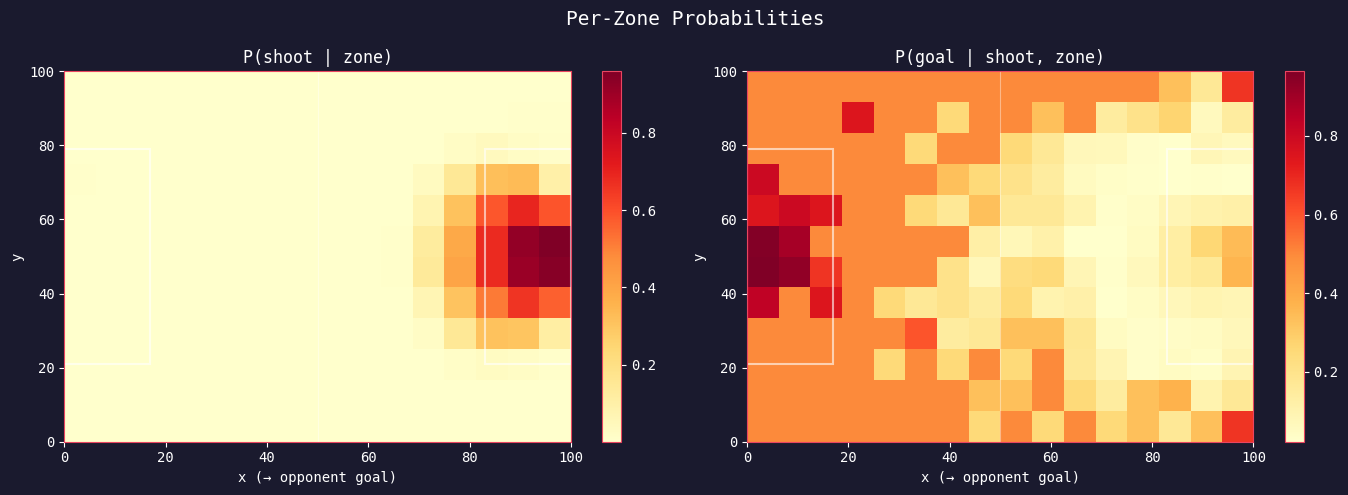

In [4]:
# Count actions per cell
shot_count = np.zeros((M, N))
goal_count = np.zeros((M, N))
pass_count = np.zeros((M, N))

np.add.at(shot_count, (si, sj), 1)
np.add.at(goal_count, (si[goals_mask], sj[goals_mask]), 1)
np.add.at(pass_count, (pi, pj), 1)

action_count = shot_count + pass_count

# Probabilities with Laplace smoothing (+1 pseudocount)
shot_prob = (shot_count + 1) / (action_count + 2)   # P(shoot | in zone)
move_prob = (pass_count + 1) / (action_count + 2)   # P(move  | in zone)
goal_prob = (goal_count + 1) / (shot_count  + 2)    # P(goal  | shoot from zone)

print('Action counts summary:')
print(f'  Total shots in grid  : {shot_count.sum():.0f}')
print(f'  Total goals in grid  : {goal_count.sum():.0f}')
print(f'  Total passes in grid : {pass_count.sum():.0f}')
print(f'  Cells with 0 actions : {(action_count == 0).sum()}')
print(f'\nProbability ranges:')
print(f'  shot_prob : [{shot_prob.min():.4f}, {shot_prob.max():.4f}]')
print(f'  goal_prob : [{goal_prob.min():.4f}, {goal_prob.max():.4f}]')
print(f'  move_prob : [{move_prob.min():.4f}, {move_prob.max():.4f}]')

# Visualise shot probability and goal probability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Per-Zone Probabilities', fontsize=14, color='white')

for ax, mat, title in zip(axes,
    [shot_prob.T, goal_prob.T],
    ['P(shoot | zone)', 'P(goal | shoot, zone)']
):
    im = ax.imshow(mat, origin='lower', aspect='auto',
                   extent=[0, 100, 0, 100], cmap='YlOrRd')
    plt.colorbar(im, ax=ax)
    # Pitch outline
    ax.add_patch(plt.Rectangle((83, 21.1), 17, 57.8, fill=False, ec='white', lw=1.5, alpha=0.6))
    ax.add_patch(plt.Rectangle((0,  21.1), 17, 57.8, fill=False, ec='white', lw=1.5, alpha=0.6))
    ax.axvline(50, color='white', lw=0.8, alpha=0.4)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_title(title, color='white')
    ax.set_xlabel('x (→ opponent goal)'); ax.set_ylabel('y')

plt.tight_layout()
plt.show()


---
## 4. Transition Matrix

$$T[i,j,k,l] = P(\text{pass ends in cell}(k,l) \mid \text{pass starts in cell}(i,j))$$

The matrix has shape **(M, N, M, N) = (16, 12, 16, 12)** — 36,864 entries.
Most are zero (most cells don't receive passes from every other cell).

We also visualise the *average pass destination* for each origin cell as a heatmap.


Building transition matrix (16 x 12 x 16 x 12) ...
  Non-zero entries: 22,064  out of 36,864  (59.85%)
  Row-sum check (should be ≈1 for populated cells):
    min=1.0000  max=1.0000  mean=1.0000


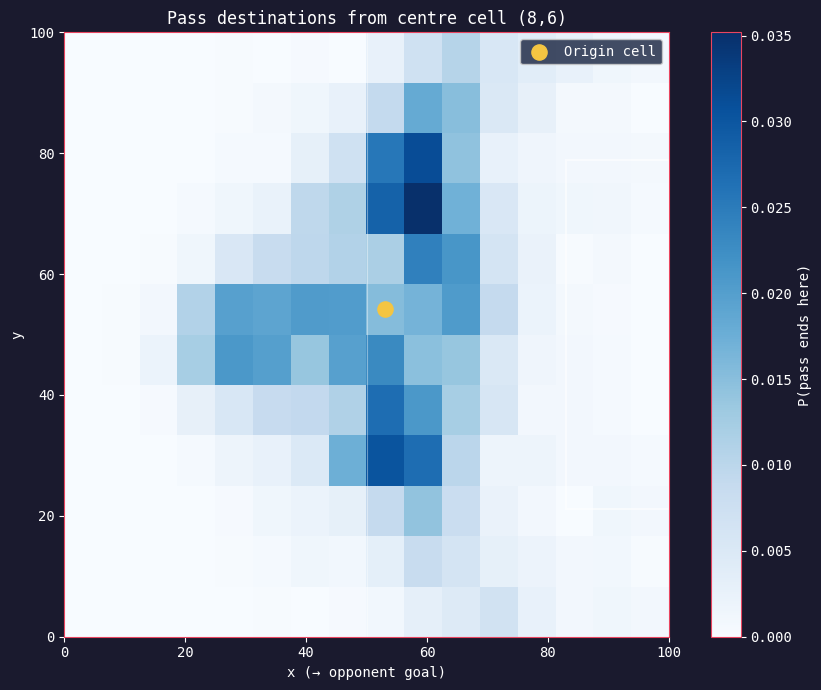

In [5]:
print('Building transition matrix (16 x 12 x 16 x 12) ...')
T = np.zeros((M, N, M, N))
np.add.at(T, (pi, pj, ei, ej), 1)
# Normalise: rows sum to 1 (or 0 for cells with no outgoing passes)
row_sums = pass_count[:, :, np.newaxis, np.newaxis]
T /= np.maximum(row_sums, 1)

print(f'  Non-zero entries: {(T > 0).sum():,}  '
      f'out of {T.size:,}  ({100*(T > 0).mean():.2f}%)')
print(f'  Row-sum check (should be ≈1 for populated cells):')
rs = T.sum(axis=(2, 3))
populated = pass_count > 0
print(f'    min={rs[populated].min():.4f}  max={rs[populated].max():.4f}  '
      f'mean={rs[populated].mean():.4f}')

# Visualise: for a central cell, show destination probability
cx, cy = 8, 6   # ~centre of pitch
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(T[cx, cy].T, origin='lower', aspect='auto',
               extent=[0, 100, 0, 100], cmap='Blues')
plt.colorbar(im, ax=ax, label='P(pass ends here)')
ax.scatter([cx / M * 100 + 100 / M / 2],
           [cy / N * 100 + 100 / N / 2],
           color=GOLD, s=120, zorder=5, label='Origin cell')
ax.add_patch(plt.Rectangle((83, 21.1), 17, 57.8, fill=False, ec='white', lw=1.5, alpha=0.6))
ax.axvline(50, color='white', lw=0.8, alpha=0.4)
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.set_aspect('equal')
ax.set_title(f'Pass destinations from centre cell ({cx},{cy})', color='white')
ax.set_xlabel('x (→ opponent goal)'); ax.set_ylabel('y')
ax.legend()
plt.tight_layout()
plt.show()


---
## 5. Solving for xT

The Bellman equation is iterated from an initial estimate until convergence:

1. Initialise: $xT^{(0)}[i,j] = P(\text{shoot}) \times P(\text{goal}|\text{shoot})$
2. Update:
$$xT^{(t+1)}[i,j] = P(\text{shoot}) \cdot P(\text{goal}) + P(\text{move}) \cdot \sum_{k,l} T[i,j,k,l] \cdot xT^{(t)}[k,l]$$
3. Repeat until $\max|xT^{(t+1)} - xT^{(t)}| < 10^{-6}$

A final **Gaussian blur** (σ=1) smooths noise from sparsely observed cells.


In [6]:
N_ITER   = 10
SIGMA    = 1.0   # Gaussian smoothing

xT = shot_prob * goal_prob   # initial estimate

print(f'Iterating Bellman equation (max {N_ITER} rounds) ...')
for it in range(N_ITER):
    xT_new = shot_prob * goal_prob + move_prob * np.einsum('ijkl,kl->ij', T, xT)
    delta  = float(np.max(np.abs(xT_new - xT)))
    xT     = xT_new
    print(f'  iter {it+1:2d}   max_delta = {delta:.2e}')
    if delta < 1e-6:
        print('  Converged.')
        break

# Gaussian smoothing to reduce sparse-cell noise
xT = gaussian_filter(xT, sigma=SIGMA)
xT = np.clip(xT, 0, None)

print(f'\nxT summary:')
print(f'  Range  : [{xT.min():.5f}, {xT.max():.5f}]')
print(f'  Defensive half (x<50) mean : {xT[:M//2, :].mean():.5f}')
print(f'  Attacking half (x>50) mean : {xT[M//2:, :].mean():.5f}')
print(f'  Penalty area  (x>83)  mean : {xT[int(0.83*M):, :].mean():.5f}')


Iterating Bellman equation (max 10 rounds) ...
  iter  1   max_delta = 1.34e-01
  iter  2   max_delta = 5.29e-02
  iter  3   max_delta = 2.53e-02
  iter  4   max_delta = 1.73e-02
  iter  5   max_delta = 1.38e-02
  iter  6   max_delta = 1.20e-02
  iter  7   max_delta = 1.06e-02
  iter  8   max_delta = 9.72e-03
  iter  9   max_delta = 9.03e-03
  iter 10   max_delta = 8.73e-03

xT summary:
  Range  : [0.05121, 0.24769]
  Defensive half (x<50) mean : 0.06178
  Attacking half (x>50) mean : 0.12568
  Penalty area  (x>83)  mean : 0.16619


---
## 6. Visualising the xT Grid

The heatmap should show:
- Near-zero values in the defensive half
- Rising values through the middle third
- Highest values in the penalty area, especially the central channel


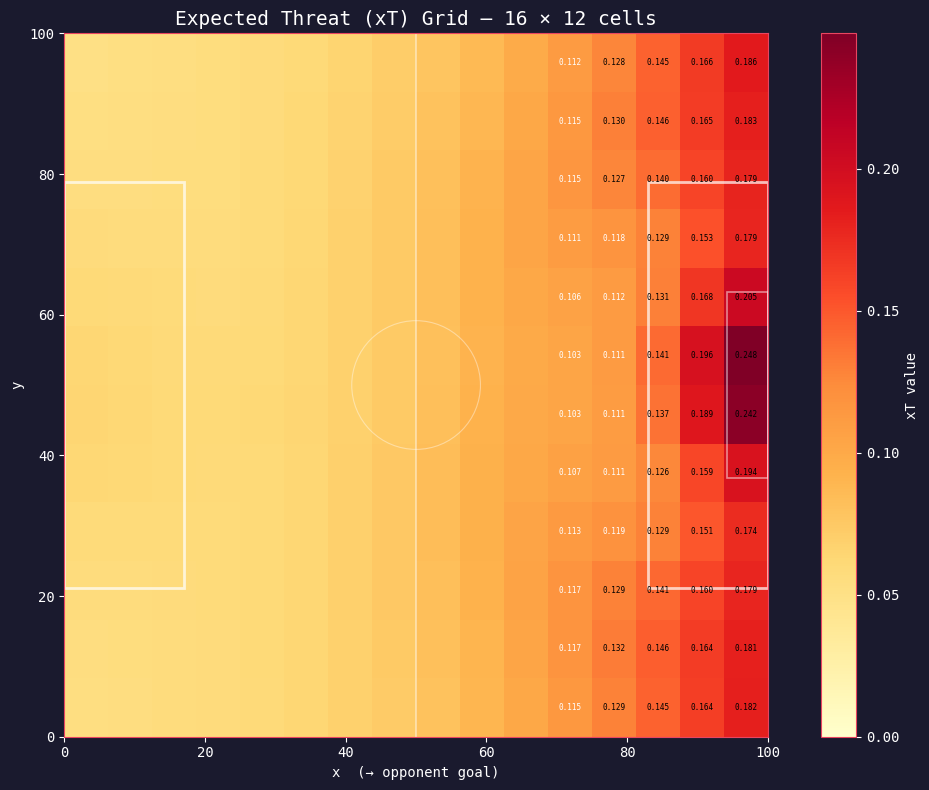

In [7]:
fig, ax = plt.subplots(figsize=(11, 8))

# Build coordinate arrays for the grid cells
x_edges = np.linspace(0, 100, M + 1)
y_edges = np.linspace(0, 100, N + 1)
x_cents = (x_edges[:-1] + x_edges[1:]) / 2
y_cents = (y_edges[:-1] + y_edges[1:]) / 2

im = ax.imshow(
    xT.T,
    origin='lower',
    extent=[0, 100, 0, 100],
    aspect='auto',
    cmap='YlOrRd',
    vmin=0,
)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('xT value', color='white')

# Pitch markings
ax.add_patch(plt.Rectangle((83, 21.1), 17, 57.8, fill=False, ec='white', lw=2, alpha=0.7))
ax.add_patch(plt.Rectangle((94.2, 36.8), 5.8, 26.4, fill=False, ec='white', lw=1.2, alpha=0.5))
ax.add_patch(plt.Rectangle((0, 21.1), 17, 57.8, fill=False, ec='white', lw=2, alpha=0.7))
ax.axvline(50, color='white', lw=1.2, alpha=0.5)
ax.add_patch(plt.Circle((50, 50), 9.15, fill=False, ec='white', lw=0.8, alpha=0.4))

# Cell-level value annotations (attacking third only)
for i in range(M):
    for j in range(N):
        if x_cents[i] > 66:
            ax.text(x_cents[i], y_cents[j], f'{xT[i,j]:.3f}',
                    ha='center', va='center', fontsize=5.5,
                    color='black' if xT[i,j] > xT.max() * 0.5 else 'white')

ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.set_aspect('equal')
ax.set_title('Expected Threat (xT) Grid — 16 × 12 cells', color='white', fontsize=14)
ax.set_xlabel('x  (→ opponent goal)'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()


---
## 7. Sanity Checks

### 7a. Monotonicity along the central channel

A 10-yard forward pass along y = 50 should always increase (or hold) xT.
Any failures suggest sparse-cell noise (addressed by smoothing).

### 7b. Named test passes

Canonical passes with known expected threat levels.


In [8]:
def xt_of_pass(x1, y1, x2, y2):
    """xT gained = xT(destination) - xT(origin), clipped at 0."""
    def lookup(x, y):
        i = int(np.clip(x / 100.0 * M, 0, M - 1))
        j = int(np.clip(y / 100.0 * N, 0, N - 1))
        return xT[i, j]
    return max(lookup(x2, y2) - lookup(x1, y1), 0.0)

# Monotonicity test — central channel forward passes
print('=== MONOTONICITY TEST  (y=50, 10-yard forward steps) ===')
print(f'{"Move":<12} {"xT(origin)":>12} {"xT(dest)":>12} {"xT gained":>12} {"Mono":>6}')
print('-' * 60)
prev_dest_xt = 0.0
ok = 0
for x1 in range(5, 95, 10):
    x2 = min(x1 + 10, 99)
    def lookup(x, y):
        i = int(np.clip(x / 100.0 * M, 0, M - 1))
        j = int(np.clip(y / 100.0 * N, 0, N - 1))
        return xT[i, j]
    xt_o = lookup(x1, 50)
    xt_d = lookup(x2, 50)
    gained = max(xt_d - xt_o, 0)
    mono = 'OK' if xt_d >= prev_dest_xt * 0.9 else 'FAIL'
    if mono == 'OK':
        ok += 1
    print(f'{x1}→{x2:<7} {xt_o:>12.5f} {xt_d:>12.5f} {gained:>12.5f} {mono:>6}')
    prev_dest_xt = xt_d
print(f'\nMonotone: {ok}/9')

# Named test cases
print('\n=== NAMED TEST PASSES ===')
test_cases = [
    ('Back-pass own half',          30, 50, 20, 50),
    ('Lateral own half',            25, 50, 25, 35),
    ('Safe forward own half',       20, 50, 35, 50),
    ('Into mid-third',              40, 50, 55, 50),
    ('Mid → final third',           55, 50, 68, 50),
    ('Into zone 14',                65, 35, 78, 50),
    ('Into box (central)',          72, 50, 88, 50),
    ('Through ball to box',         64, 50, 88, 50),
    ('Wide cross into box',         80, 15, 88, 50),
    ('Cut-back from byline',        97, 18, 88, 50),
    ('Near-post tap-in',            92, 44, 97, 48),
]
print(f'{"Pass Type":<32} {"xT":>10}')
print('-' * 44)
for desc, x1, y1, x2, y2 in test_cases:
    print(f'{desc:<32} {xt_of_pass(x1, y1, x2, y2):>10.4f}')


=== MONOTONICITY TEST  (y=50, 10-yard forward steps) ===
Move           xT(origin)     xT(dest)    xT gained   Mono
------------------------------------------------------------
5→15           0.06364      0.05992      0.00000     OK
15→25           0.05992      0.06062      0.00070     OK
25→35           0.06062      0.06356      0.00294     OK
35→45           0.06356      0.07403      0.01047     OK
45→55           0.07403      0.08211      0.00809     OK
55→65           0.08211      0.09939      0.01728     OK
65→75           0.09939      0.11141      0.01202     OK
75→85           0.11141      0.14099      0.02958     OK
85→95           0.14099      0.24769      0.10670     OK

Monotone: 9/9

=== NAMED TEST PASSES ===
Pass Type                                xT
--------------------------------------------
Back-pass own half                   0.0000
Lateral own half                     0.0001
Safe forward own half                0.0040
Into mid-third                       0.0141
Mid 

---
## 8. xT on Sample Passes — Pitch Plot

Visualise a set of high-xT and low-xT passes on an mplsoccer pitch.
Arrow colour = xT gained; thicker arrows = higher value.


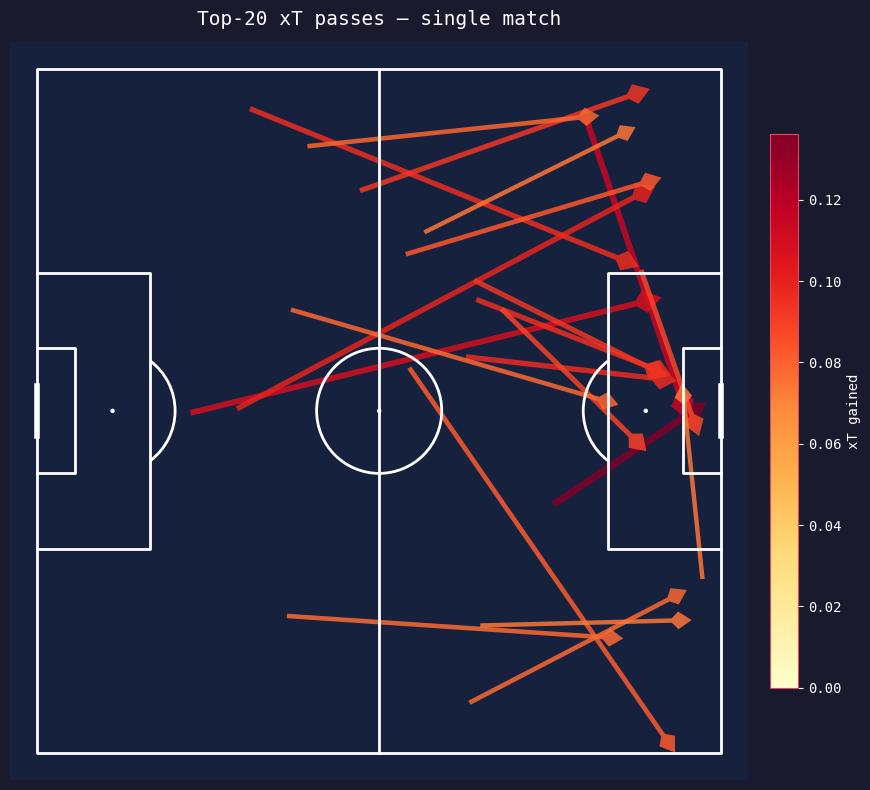

Top-20 passes xT summary:
   x    y  Pass End X  Pass End Y  xT_gained
75.5 36.3        97.8        51.2   0.136207
80.2 93.0        95.2        48.7   0.113950
22.4 49.7        91.3        66.6   0.108061
29.2 50.3        90.4        82.9   0.099043
62.7 57.9        93.5        54.4   0.096800
31.1 94.2        88.0        71.1   0.095787
64.2 66.3        92.7        55.2   0.095381
63.9 69.1        92.1        55.0   0.093593
47.2 82.2        89.6        97.1   0.092585
67.9 64.9        89.1        44.1   0.088498
88.3 70.6        96.8        46.3   0.088199
53.9 72.9        91.3        84.1   0.082701
54.4 56.3        93.3         0.0   0.081532
39.5 88.7        82.2        93.2   0.078376
37.1 64.8        85.0        50.9   0.078090
63.2  7.3        95.0        23.8   0.077989
36.5 20.0        85.7        16.7   0.077663
56.6 76.1        87.5        91.5   0.074128
64.8 18.6        95.7        19.4   0.074128
97.3 25.4        94.3        54.0   0.073491


In [9]:
# Sample real passes from the first Barcelona match
import random

barca_f = glob.glob(str(ROOT / 'data/barcelona/result/**/match_event/*.parquet'), recursive=True)[0]
match_df = pd.read_parquet(barca_f, columns=['event_type','x','y','Pass End X','Pass End Y','team_code'])
for c in ['x','y','Pass End X','Pass End Y']:
    match_df[c] = pd.to_numeric(match_df[c], errors='coerce')

match_passes = match_df[
    (match_df['event_type'] == 'Pass')
    & match_df['x'].notna() & match_df['Pass End X'].notna()
].copy()

match_passes['xT_gained'] = [
    xt_of_pass(r['x'], r['y'], r['Pass End X'], r['Pass End Y'])
    for _, r in match_passes.iterrows()
]

top_passes = match_passes.nlargest(20, 'xT_gained')

pitch = Pitch(pitch_color='#16213e', line_color='white', pitch_type='custom',
              pitch_length=100, pitch_width=100, line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor('#1a1a2e')

norm  = mcolors.Normalize(vmin=0, vmax=top_passes['xT_gained'].max())
cmap  = plt.cm.YlOrRd

for _, row in top_passes.iterrows():
    c = cmap(norm(row['xT_gained']))
    lw = 1 + row['xT_gained'] / top_passes['xT_gained'].max() * 4
    pitch.arrows(row['x'], row['y'], row['Pass End X'], row['Pass End Y'],
                 ax=ax, color=c, width=lw, headwidth=4, headlength=3, alpha=0.85)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('xT gained', color='white')

ax.set_title('Top-20 xT passes — single match', color='white', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

print(f'Top-20 passes xT summary:')
print(top_passes[['x','y','Pass End X','Pass End Y','xT_gained']].to_string(index=False))


---
## 9. Known Limitations

| # | Limitation | Effect |
|---|------------|--------|
| 1 | **No ball carries** (Opta does not record carries) | Ball-carrying wingers and progressive midfielders are under-credited. xT accrues to the passer, not the carrier. **Caveat all player rankings.** |
| 2 | **Uniform zone xT** | Every pass into a zone gets the same destination value, regardless of shot angle or pressure. |
| 3 | **La Liga + European opposition only** | May not generalise to other leagues with different press / passing styles. |
| 4 | **Laplace smoothing in sparse zones** | Corner regions and deep defensive cells have very few observations; smoothed probabilities there are dominated by the pseudocount prior. |


---
## 10. Save Model

In [10]:
import joblib

SAVE = True

if SAVE:
    MODEL_DIR = ROOT / 'xT_model'
    out = MODEL_DIR / 'xt_grid.npy'
    np.save(out, xT)
    print(f'Saved {out}  shape={xT.shape}')
    print('Load in predictor via: from xT_model.predictor import predict_xt, add_xt_column')
else:
    print('SAVE=False — nothing written.')


Saved /Users/rishirajsinharay/Desktop/Final-Masters-Project/xT_model/xt_grid.npy  shape=(16, 12)
Load in predictor via: from xT_model.predictor import predict_xt, add_xt_column
